# Architecture Comparison — DenseNet121 vs EfficientNet-B2 vs ResNet-50 vs VGG-16
### Reconstructed baseline comparison notebook

This notebook reconstructs the lost architecture-comparison run referenced in the optimization
notebook (`baseline_comparison.ipynb`), where DenseNet121 was identified as the best-performing
backbone (~76% baseline validation accuracy).

**What this notebook does:**
- Trains the same dual-input architecture (full mammogram + cropped lesion, concatenated
  features, shared classifier) with four different CNN backbones: **DenseNet121, EfficientNet-B2,
  ResNet-50, VGG-16**.
- Uses **only the Stage 0 baseline hyperparameters** from the optimization notebook
  (`head_lr=1e-4`, `backbone_lr=1e-5`, `weight_decay=1e-4`, `scheduler=plateau`) — no tuning is
  performed here, on purpose, since the goal is a fair architecture comparison, not optimization.
- Follows the exact same data loading, transforms, two-phase training procedure (head warmup then
  full fine-tuning), early stopping, and checkpointing logic as the optimization notebook.
- Evaluates each best checkpoint on the held-out test set and reports **Accuracy, Sensitivity
  (Recall), Specificity, F1-Score, and AUC-ROC**.
- Produces a single grouped bar chart comparing all four models across all five metrics.

> Note: because the original comparison notebook was lost, this is a faithful re-implementation
> based on the pipeline and hyperparameters documented in `baseline_comparison.ipynb`. Results will
> only match the original run if the same data splits, seed, and environment are used.


In [4]:
# --- Install / import dependencies ---
import os, time, json, random, warnings, gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())


PyTorch: 2.11.0+cu128 | CUDA available: True


In [5]:
# --- Load dataframes (same as the optimization notebook) ---
# Expected columns: ["patient_id", "pathology", "image file path",
#                     "cropped image file path", "full image cached path",
#                     "cropped image cached path"]
train_df = pd.read_csv("../../dataframes/train_df_final.csv")
val_df   = pd.read_csv("../../dataframes/val_df_final.csv")
test_df  = pd.read_csv("../../dataframes/test_df_final.csv")

print("train:", len(train_df), "val:", len(val_df), "test:", len(test_df))


train: 2599 val: 328 test: 326


In [6]:
# --- Global configuration (identical to the optimization notebook) ---
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 16
NUM_WORKERS = 4 if os.name != "nt" else 0

HEAD_WARMUP_EPOCHS = 5      # Phase 1: backbones frozen, head-only
MAX_EPOCHS = 40             # capped per-experiment budget (Phase 1 + Phase 2)
EARLY_STOPPING_PATIENCE = 8

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

FULL_PATH_COL = "full image cached path"
CROP_PATH_COL = "cropped image cached path"
LABEL_COL = "pathology"
CLASS_NAMES = ["Benign", "Malignant"]

# Stage 0 baseline config — the ONLY hyperparameters used in this notebook.
# Taken directly from BASELINE in baseline_comparison.ipynb. Nothing here is tuned.
BASELINE = dict(
    head_lr=1e-4,
    backbone_lr=1e-5,
    weight_decay=1e-4,
    scheduler="plateau",   # "plateau" | "cosine" | "onecycle"
)

# The four backbones being compared. Values are torchvision model identifiers used below.
ARCHITECTURES = ["densenet121", "resnet50", "efficientnet_b2", "vgg16"]
ARCH_DISPLAY_NAMES = {
    "densenet121": "DenseNet121",
    "resnet50": "ResNet-50",
    "efficientnet_b2": "EfficientNet-B2",
    "vgg16": "VGG-16",
}

RESULTS_DIR = "results"
CKPT_DIR = "checkpoints"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def free_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


In [7]:
# --- Label encoding, transforms, dataset (identical to the optimization notebook) ---
def encode_label(raw_label):
    try:
        return int(raw_label)
    except (ValueError, TypeError):
        pass
    text = str(raw_label).strip().upper()
    return 1 if "MALIGNANT" in text else 0


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class DualImageDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        full_image = Image.open(row[FULL_PATH_COL]).convert("RGB")
        cropped_image = Image.open(row[CROP_PATH_COL]).convert("RGB")
        full_image = self.transform(full_image)
        cropped_image = self.transform(cropped_image)
        label = torch.tensor(encode_label(row[LABEL_COL]), dtype=torch.long)
        return full_image, cropped_image, label


def make_loaders(batch_size=BATCH_SIZE):
    train_loader = DataLoader(
        DualImageDataset(train_df, train_transform), batch_size=batch_size,
        shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True,
    )
    val_loader = DataLoader(
        DualImageDataset(val_df, eval_transform), batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    test_loader = DataLoader(
        DualImageDataset(test_df, eval_transform), batch_size=batch_size,
        shuffle=False, num_workers=NUM_WORKERS, pin_memory=True,
    )
    return train_loader, val_loader, test_loader


## Dual-input model — generalized across backbones

Same architecture pattern as the optimization notebook (two independent backbones — one for the
full mammogram, one for the cropped lesion — feeding a shared classifier), but the backbone
constructor is now parameterized so the identical classifier head and forward/training logic is
reused unchanged across all four CNNs. Only the feature extractor and its output dimensionality
differ per architecture; everything else (dropout, hidden layer sizes, freezing behavior) is kept
identical across models so the comparison isolates the backbone choice.

In [8]:
# --- Generalized backbone builder for the 4 architectures under comparison ---
def build_backbone(arch):
    """Returns (feature_extractor, output_dim) for the given architecture.
    Each extractor ends in global average pooling so all backbones produce a flat
    feature vector, keeping the downstream classifier identical across models."""
    if arch == "densenet121":
        weights = models.DenseNet121_Weights.IMAGENET1K_V1
        base = models.densenet121(weights=weights)
        extractor = nn.Sequential(base.features, nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d((1, 1)))
        dim = 1024
    elif arch == "resnet50":
        weights = models.ResNet50_Weights.IMAGENET1K_V2
        base = models.resnet50(weights=weights)
        extractor = nn.Sequential(*list(base.children())[:-1])  # drop the fc layer, keep avgpool
        dim = 2048
    elif arch == "efficientnet_b2":
        weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1
        base = models.efficientnet_b2(weights=weights)
        extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d((1, 1)))
        dim = 1408
    elif arch == "vgg16":
        weights = models.VGG16_Weights.IMAGENET1K_V1
        base = models.vgg16(weights=weights)
        extractor = nn.Sequential(base.features, nn.AdaptiveAvgPool2d((1, 1)))
        dim = 512
    else:
        raise ValueError(f"Unknown architecture: {arch}")
    return extractor, dim


class DualInputModel(nn.Module):
    """Same dual-input design as DualInputDenseNet in the optimization notebook,
    generalized to accept any of the four backbone architectures."""

    def __init__(self, arch, num_classes=2, dropout=0.5):
        super().__init__()
        self.arch = arch
        self.full_extractor, feat_dim_full = build_backbone(arch)
        self.crop_extractor, feat_dim_crop = build_backbone(arch)
        combined_dim = feat_dim_full + feat_dim_crop
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 512), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, full_image, cropped_image):
        full_feat = torch.flatten(self.full_extractor(full_image), 1)
        crop_feat = torch.flatten(self.crop_extractor(cropped_image), 1)
        combined = torch.cat([full_feat, crop_feat], dim=1)
        return self.classifier(combined)

    def set_backbones_trainable(self, trainable: bool):
        for extractor in (self.full_extractor, self.crop_extractor):
            for p in extractor.parameters():
                p.requires_grad = trainable
            extractor.train(trainable)


In [9]:
# --- Metrics + epoch runner ---
# Extended with Sensitivity (= Recall on the positive/Malignant class) and Specificity
# (= Recall on the negative/Benign class), on top of the metrics already computed in the
# optimization notebook, since the requested report needs both.
def compute_metrics(labels, preds, probs):
    acc = accuracy_score(labels, preds)
    sensitivity = recall_score(labels, preds, pos_label=1, zero_division=0)  # a.k.a. recall
    cm = confusion_matrix(labels, preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else float("nan")
    f1 = f1_score(labels, preds, zero_division=0)
    try:
        auc = roc_auc_score(labels, probs)
    except ValueError:
        auc = float("nan")
    return {
        "accuracy": acc, "sensitivity": sensitivity, "specificity": specificity,
        "f1": f1, "roc_auc": auc,
    }


def run_epoch(model, loader, device, criterion, optimizer=None, scaler=None, use_amp=False, desc=""):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds, all_labels, all_probs = [], [], []

    grad_context = torch.enable_grad() if is_train else torch.no_grad()
    with grad_context:
        for full_imgs, crop_imgs, labels in tqdm(loader, desc=desc, leave=False):
            full_imgs = full_imgs.to(device, non_blocking=True)
            crop_imgs = crop_imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(full_imgs, crop_imgs)
                loss = criterion(outputs, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())

    avg_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return avg_loss, metrics, (all_labels, all_preds, all_probs)


In [10]:
# --- Scheduler builder (identical to the optimization notebook) ---
def build_scheduler(name, optimizer, steps_per_epoch=None, total_epochs=None):
    if name == "plateau":
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=5), "epoch"
    if name == "cosine":
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(total_epochs, 1)), "epoch"
    if name == "onecycle":
        max_lrs = [g["lr"] for g in optimizer.param_groups]
        sched = optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=max_lrs, steps_per_epoch=steps_per_epoch, epochs=total_epochs,
        )
        return sched, "batch"
    raise ValueError(f"Unknown scheduler: {name}")


def train_experiment(exp_name, arch, head_lr, backbone_lr, weight_decay, scheduler_name,
                      train_loader, val_loader, max_epochs=MAX_EPOCHS):
    """Trains one DualInputModel(arch) from fresh ImageNet weights with the given
    hyperparameters, using the exact two-phase (head warmup -> full fine-tune) procedure
    from the optimization notebook. Returns (history_dict, best_checkpoint_dict, result_row)."""
    set_seed(SEED)
    print(f"\n{'='*80}\nExperiment: {exp_name}  (arch={arch})\n"
          f"head_lr={head_lr} backbone_lr={backbone_lr} weight_decay={weight_decay} "
          f"scheduler={scheduler_name}\n{'='*80}")

    model = DualInputModel(arch).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    use_amp = DEVICE.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
    ckpt_path = os.path.join(CKPT_DIR, f"{exp_name}.pth")

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
    best_val_loss, best_val_acc, global_epoch = float("inf"), 0.0, 0
    start_time = time.time()

    # ---- Phase 1: head warmup, backbones frozen ----
    model.set_backbones_trainable(False)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=head_lr, weight_decay=weight_decay,
    )
    for _ in range(min(HEAD_WARMUP_EPOCHS, max_epochs)):
        global_epoch += 1
        tr_loss, tr_m, _ = run_epoch(model, train_loader, DEVICE, criterion, optimizer, scaler, use_amp,
                                      desc=f"{exp_name} e{global_epoch} [warmup-train]")
        va_loss, va_m, _ = run_epoch(model, val_loader, DEVICE, criterion,
                                      desc=f"{exp_name} e{global_epoch} [warmup-val]")
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[0]["lr"])
        print(f"  [warmup] epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f}")
        if va_loss < best_val_loss:
            best_val_loss, best_val_acc = va_loss, va_m["accuracy"]
            torch.save({"epoch": global_epoch - 1, "model_state_dict": model.state_dict(),
                        "val_accuracy": va_m["accuracy"], "val_loss": va_loss}, ckpt_path)

    # ---- Phase 2: unfreeze backbones, discriminative LR ----
    model.set_backbones_trainable(True)
    optimizer = optim.AdamW([
        {"params": model.full_extractor.parameters(), "lr": backbone_lr},
        {"params": model.crop_extractor.parameters(), "lr": backbone_lr},
        {"params": model.classifier.parameters(), "lr": head_lr},
    ], weight_decay=weight_decay)

    remaining_epochs = max(max_epochs - HEAD_WARMUP_EPOCHS, 0)
    scheduler, step_mode = build_scheduler(scheduler_name, optimizer,
                                            steps_per_epoch=len(train_loader), total_epochs=max(remaining_epochs, 1))
    epochs_no_improve = 0

    for _ in range(remaining_epochs):
        global_epoch += 1
        model.train()
        running_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
        for full_imgs, crop_imgs, labels in tqdm(train_loader, desc=f"{exp_name} e{global_epoch} [train]", leave=False):
            full_imgs = full_imgs.to(DEVICE, non_blocking=True)
            crop_imgs = crop_imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(full_imgs, crop_imgs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            if step_mode == "batch":
                scheduler.step()
            running_loss += loss.item() * labels.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
            all_probs.extend(probs.detach().cpu().numpy())
        tr_loss = running_loss / len(train_loader.dataset)
        tr_m = compute_metrics(all_labels, all_preds, all_probs)

        va_loss, va_m, _ = run_epoch(model, val_loader, DEVICE, criterion,
                                      desc=f"{exp_name} e{global_epoch} [val]")
        if step_mode == "epoch":
            if scheduler_name == "plateau":
                scheduler.step(va_loss)
            else:
                scheduler.step()

        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_m["accuracy"]); history["val_acc"].append(va_m["accuracy"])
        history["lr"].append(optimizer.param_groups[-1]["lr"])
        print(f"  epoch {global_epoch:2d} | train_loss {tr_loss:.4f} acc {tr_m['accuracy']:.4f} "
              f"| val_loss {va_loss:.4f} acc {va_m['accuracy']:.4f} | lr(head) {optimizer.param_groups[-1]['lr']:.2e}")

        if va_loss < best_val_loss:
            best_val_loss, best_val_acc, epochs_no_improve = va_loss, va_m["accuracy"], 0
            torch.save({"epoch": global_epoch - 1, "model_state_dict": model.state_dict(),
                        "optimizer_state_dict": optimizer.state_dict(),
                        "val_accuracy": va_m["accuracy"], "val_loss": va_loss}, ckpt_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print(f"  Early stopping at epoch {global_epoch}.")
                break

    elapsed = time.time() - start_time
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])

    del model
    free_gpu()

    result_row = {
        "experiment": exp_name, "architecture": arch,
        "head_lr": head_lr, "backbone_lr": backbone_lr,
        "weight_decay": weight_decay, "scheduler": scheduler_name,
        "best_epoch": checkpoint["epoch"] + 1, "epochs_run": global_epoch,
        "best_val_loss": checkpoint["val_loss"], "best_val_accuracy": checkpoint["val_accuracy"],
        "training_time_sec": round(elapsed, 1), "checkpoint_path": ckpt_path,
    }
    return history, checkpoint, result_row


In [11]:
# --- Full evaluation (val or test set) for the best checkpoint of an experiment ---
def evaluate_checkpoint(ckpt_path, arch, loader, tag=""):
    model = DualInputModel(arch).to(DEVICE)
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for full_imgs, crop_imgs, labels in tqdm(loader, desc=f"eval {tag}", leave=False):
            full_imgs, crop_imgs = full_imgs.to(DEVICE), crop_imgs.to(DEVICE)
            outputs = model(full_imgs, crop_imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0)
    del model
    free_gpu()
    return {"metrics": metrics, "confusion_matrix": cm, "report": report,
            "labels": all_labels, "preds": all_preds, "probs": all_probs}


In [12]:
# --- Plotting helpers ---
def plot_curves(history, title_prefix):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train")
    axes[0].plot(epochs, history["val_loss"], label="Val")
    axes[0].set_title(f"{title_prefix} — Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train")
    axes[1].plot(epochs, history["val_acc"], label="Val")
    axes[1].set_title(f"{title_prefix} — Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

    axes[2].plot(epochs, history["lr"])
    axes[2].set_title(f"{title_prefix} — Learning Rate"); axes[2].set_xlabel("Epoch"); axes[2].set_yscale("log")

    plt.tight_layout(); plt.show()


def plot_confusion_and_roc(eval_result, title_prefix):
    labels, probs = eval_result["labels"], eval_result["probs"]
    cm = eval_result["confusion_matrix"]
    fpr, tpr, _ = roc_curve(labels, probs)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].imshow(cm, cmap="Blues")
    axes[0].set_title(f"{title_prefix} — Confusion Matrix (test)")
    axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(CLASS_NAMES)
    axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(CLASS_NAMES)
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha="center", va="center")

    axes[1].plot(fpr, tpr, label=f"AUC={eval_result['metrics']['roc_auc']:.3f}")
    axes[1].plot([0, 1], [0, 1], "--", color="gray")
    axes[1].set_title(f"{title_prefix} — ROC Curve (test)"); axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR"); axes[1].legend()

    plt.tight_layout(); plt.show()
    print(eval_result["report"])


## Train all four architectures — Stage 0 baseline hyperparameters only

Each model is trained from fresh ImageNet weights using **exactly** `BASELINE` (`head_lr=1e-4`,
`backbone_lr=1e-5`, `weight_decay=1e-4`, `scheduler=plateau`) — the same config, same seed, same
epoch budget/early stopping, same data splits and loaders as Stage 0 in the optimization notebook.
No hyperparameter search is performed; this cell exists purely to reproduce the architecture
comparison.


Experiment: stage0_baseline_densenet121  (arch=densenet121)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau


  [warmup] epoch  1 | train_loss 0.6762 acc 0.5833 | val_loss 0.6463 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6516 acc 0.6057 | val_loss 0.6162 acc 0.6250


  [warmup] epoch  3 | train_loss 0.6403 acc 0.6231 | val_loss 0.5917 acc 0.6433


  [warmup] epoch  4 | train_loss 0.6151 acc 0.6593 | val_loss 0.5642 acc 0.6951


...

  epoch 16 | train_loss 0.3383 acc 0.8580 | val_loss 0.5149 acc 0.7774 | lr(head) 1.00e-04


  epoch 17 | train_loss 0.3209 acc 0.8526 | val_loss 0.5554 acc 0.7652 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3225 acc 0.8549 | val_loss 0.5256 acc 0.7805 | lr(head) 1.00e-05


  epoch 19 | train_loss 0.2841 acc 0.8777 | val_loss 0.5247 acc 0.7866 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.2841 acc 0.8735 | val_loss 0.5139 acc 0.7896 | lr(head) 1.00e-05
  Early stopping at epoch 20.


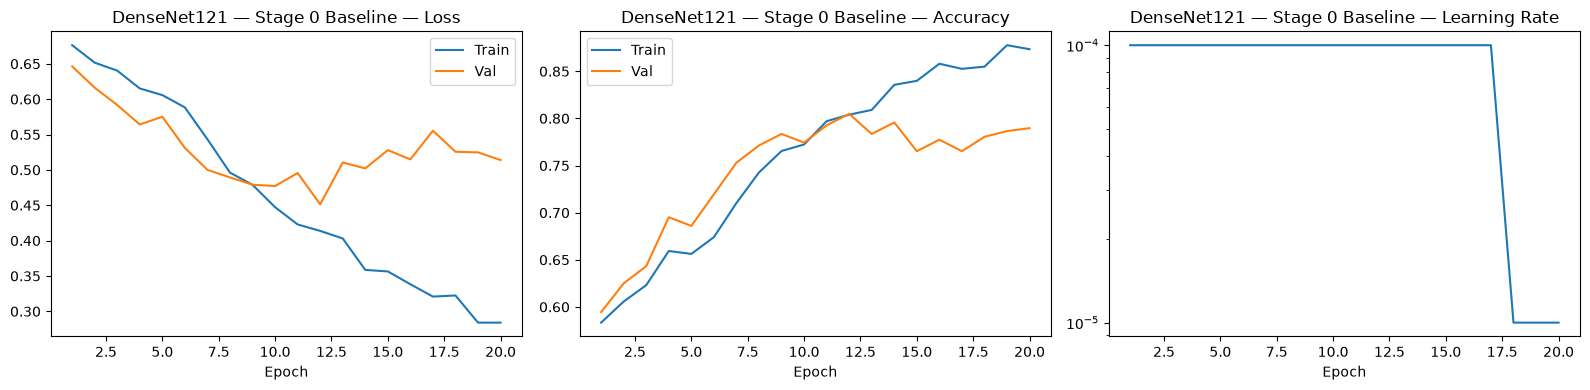

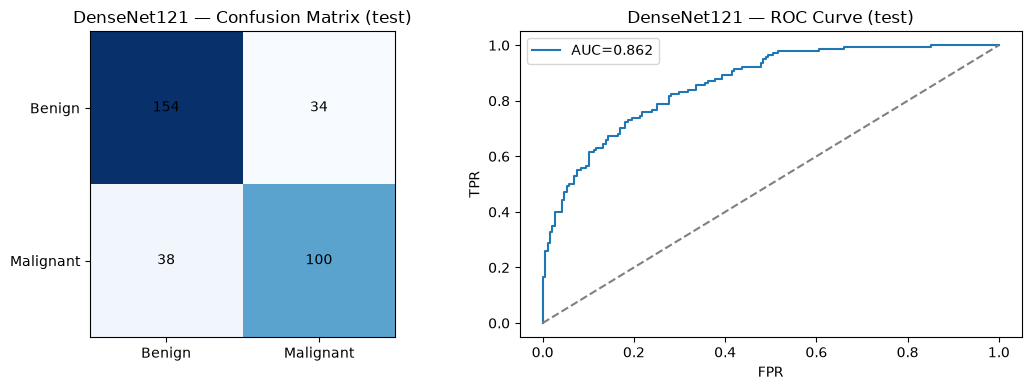

              precision    recall  f1-score   support

      Benign       0.80      0.82      0.81       188
   Malignant       0.75      0.72      0.74       138

    accuracy                           0.78       326
   macro avg       0.77      0.77      0.77       326
weighted avg       0.78      0.78      0.78       326


Experiment: stage0_baseline_resnet50  (arch=resnet50)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau


  [warmup] epoch  1 | train_loss 0.6684 acc 0.6034 | val_loss 0.6318 acc 0.6616


  [warmup] epoch  2 | train_loss 0.6303 acc 0.6447 | val_loss 0.6034 acc 0.6433


  [warmup] epoch  3 | train_loss 0.6027 acc 0.6613 | val_loss 0.5866 acc 0.6646


  [warmup] epoch  4 | train_loss 0.6009 acc 0.6694 | val_loss 0.5671 acc 0.7012


...

  epoch 13 | train_loss 0.4159 acc 0.7905 | val_loss 0.5550 acc 0.7683 | lr(head) 1.00e-04


  epoch 14 | train_loss 0.4031 acc 0.8032 | val_loss 0.5457 acc 0.7866 | lr(head) 1.00e-04


  epoch 15 | train_loss 0.3906 acc 0.8129 | val_loss 0.5357 acc 0.8018 | lr(head) 1.00e-05


  epoch 16 | train_loss 0.3681 acc 0.8275 | val_loss 0.5335 acc 0.8079 | lr(head) 1.00e-05


  epoch 17 | train_loss 0.3766 acc 0.8206 | val_loss 0.5239 acc 0.7988 | lr(head) 1.00e-05
  Early stopping at epoch 17.


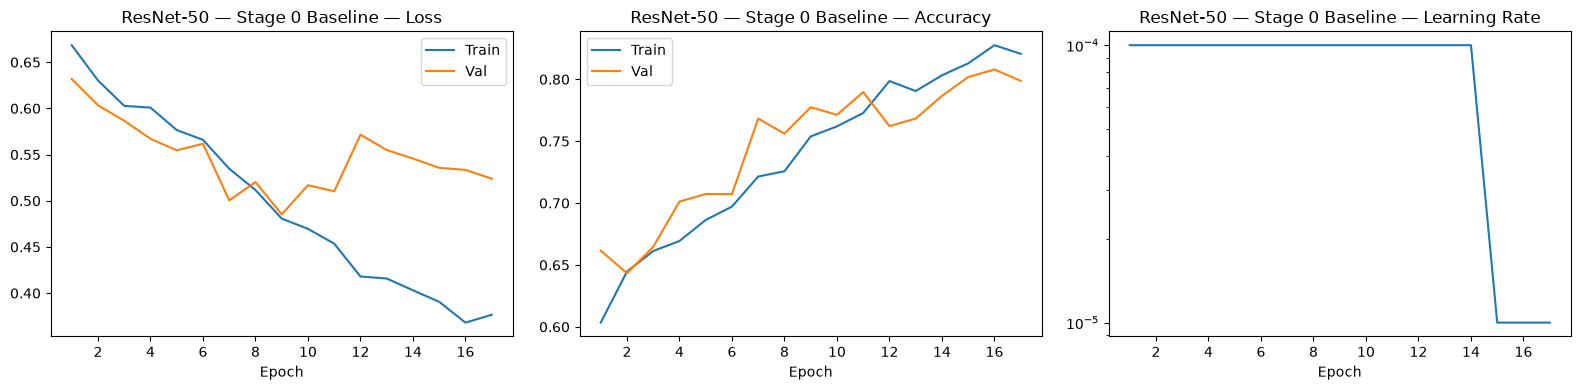

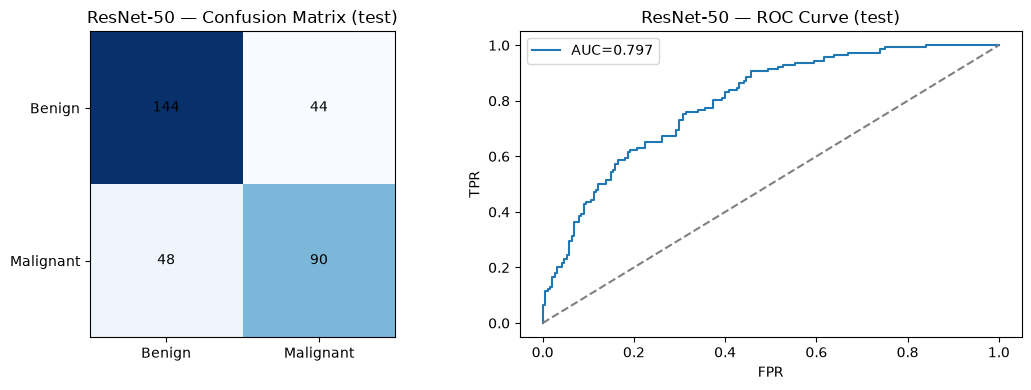

              precision    recall  f1-score   support

      Benign       0.75      0.77      0.76       188
   Malignant       0.67      0.65      0.66       138

    accuracy                           0.72       326
   macro avg       0.71      0.71      0.71       326
weighted avg       0.72      0.72      0.72       326


Experiment: stage0_baseline_efficientnet_b2  (arch=efficientnet_b2)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau


  [warmup] epoch  1 | train_loss 0.6696 acc 0.5864 | val_loss 0.6301 acc 0.6128


  [warmup] epoch  2 | train_loss 0.6300 acc 0.6373 | val_loss 0.5873 acc 0.7165


  [warmup] epoch  3 | train_loss 0.6064 acc 0.6644 | val_loss 0.5645 acc 0.7043


  [warmup] epoch  4 | train_loss 0.5897 acc 0.6644 | val_loss 0.5614 acc 0.7165


...

  epoch 17 | train_loss 0.3879 acc 0.8075 | val_loss 0.5562 acc 0.7348 | lr(head) 1.00e-04


  epoch 18 | train_loss 0.3811 acc 0.8171 | val_loss 0.5557 acc 0.7165 | lr(head) 1.00e-04


  epoch 19 | train_loss 0.3683 acc 0.8248 | val_loss 0.5373 acc 0.7348 | lr(head) 1.00e-05


  epoch 20 | train_loss 0.3542 acc 0.8380 | val_loss 0.5354 acc 0.7348 | lr(head) 1.00e-05


  epoch 21 | train_loss 0.3413 acc 0.8438 | val_loss 0.5746 acc 0.7287 | lr(head) 1.00e-05
  Early stopping at epoch 21.


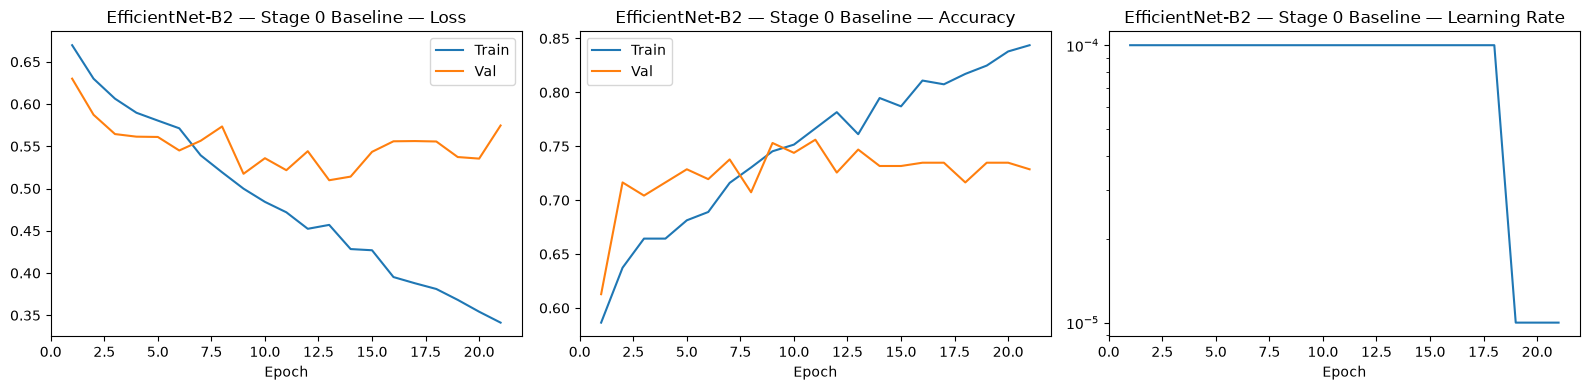

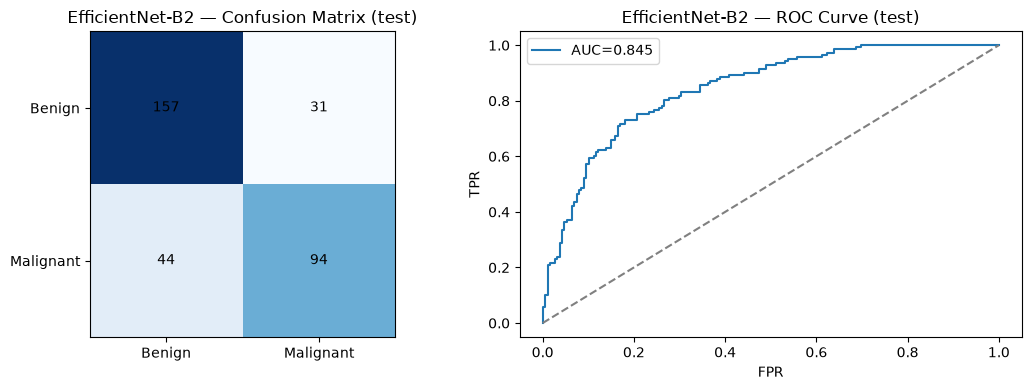

              precision    recall  f1-score   support

      Benign       0.78      0.84      0.81       188
   Malignant       0.75      0.68      0.71       138

    accuracy                           0.77       326
   macro avg       0.77      0.76      0.76       326
weighted avg       0.77      0.77      0.77       326


Experiment: stage0_baseline_vgg16  (arch=vgg16)
head_lr=0.0001 backbone_lr=1e-05 weight_decay=0.0001 scheduler=plateau


  [warmup] epoch  1 | train_loss 0.6675 acc 0.5934 | val_loss 0.6483 acc 0.5945


  [warmup] epoch  2 | train_loss 0.6361 acc 0.6327 | val_loss 0.6004 acc 0.6280


  [warmup] epoch  3 | train_loss 0.6097 acc 0.6586 | val_loss 0.5977 acc 0.6159


  [warmup] epoch  4 | train_loss 0.5986 acc 0.6721 | val_loss 0.5537 acc 0.7104


...

  epoch 13 | train_loss 0.3426 acc 0.8484 | val_loss 0.6022 acc 0.7683 | lr(head) 1.00e-04


  epoch 14 | train_loss 0.3189 acc 0.8573 | val_loss 0.5653 acc 0.7622 | lr(head) 1.00e-04


  epoch 15 | train_loss 0.3024 acc 0.8673 | val_loss 0.7570 acc 0.7134 | lr(head) 1.00e-05


  epoch 16 | train_loss 0.2430 acc 0.8931 | val_loss 0.6476 acc 0.7805 | lr(head) 1.00e-05


  epoch 17 | train_loss 0.2288 acc 0.9043 | val_loss 0.6653 acc 0.7835 | lr(head) 1.00e-05
  Early stopping at epoch 17.


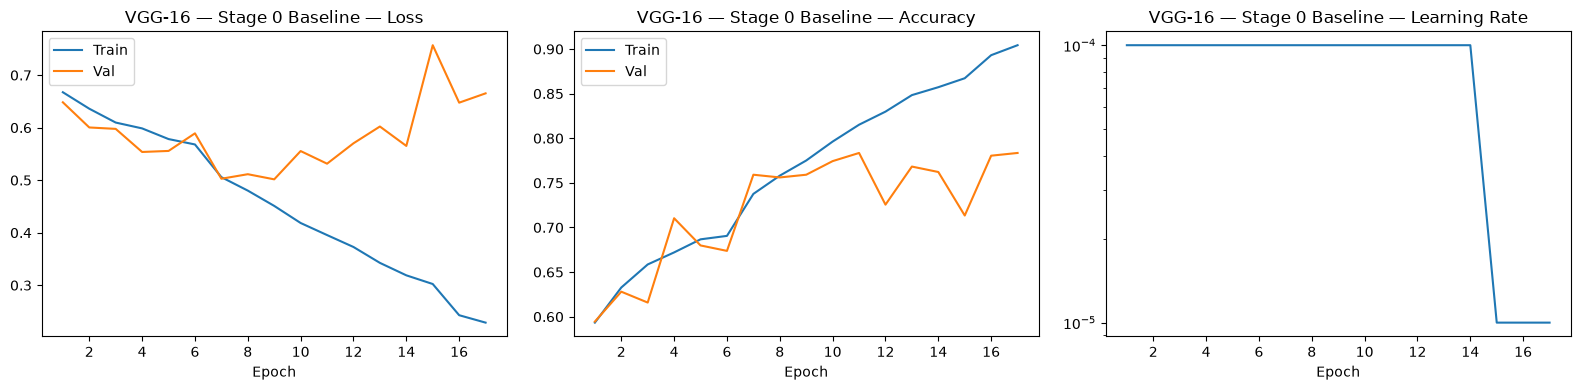

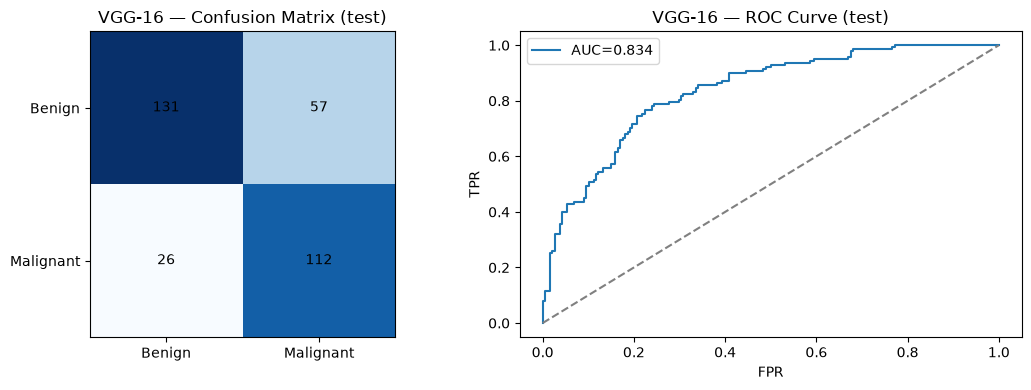

              precision    recall  f1-score   support

      Benign       0.83      0.70      0.76       188
   Malignant       0.66      0.81      0.73       138

    accuracy                           0.75       326
   macro avg       0.75      0.75      0.74       326
weighted avg       0.76      0.75      0.75       326

Saved test-set comparison metrics to results\architecture_comparison_test_metrics.csv


,model,architecture,accuracy,sensitivity,specificity,f1,roc_auc,best_val_accuracy,best_epoch,epochs_run,training_time_sec,checkpoint_path
0,DenseNet121,densenet121,0.779141,0.724638,0.819149,0.735294,0.861702,0.804878,12,20,1002.5,checkpoints\stage0_baseline_densenet121.pth
1,ResNet-50,resnet50,0.717791,0.652174,0.765957,0.661765,0.796755,0.777439,9,17,734.0,checkpoints\stage0_baseline_resnet50.pth
2,EfficientNet-B2,efficientnet_b2,0.769939,0.681159,0.835106,0.714829,0.844743,0.746951,13,21,976.6,checkpoints\stage0_baseline_efficientnet_b2.pth
3,VGG-16,vgg16,0.745399,0.811594,0.696809,0.729642,0.834258,0.759146,9,17,992.5,checkpoints\stage0_baseline_vgg16.pth


In [13]:
train_loader, val_loader, test_loader = make_loaders()

comparison_results = []
comparison_histories = {}
comparison_test_evals = {}

for arch in ARCHITECTURES:
    display_name = ARCH_DISPLAY_NAMES[arch]
    exp_name = f"stage0_baseline_{arch}"

    hist, ckpt, row = train_experiment(
        exp_name=exp_name, arch=arch,
        head_lr=BASELINE["head_lr"], backbone_lr=BASELINE["backbone_lr"],
        weight_decay=BASELINE["weight_decay"], scheduler_name=BASELINE["scheduler"],
        train_loader=train_loader, val_loader=val_loader,
    )
    comparison_histories[arch] = hist
    plot_curves(hist, f"{display_name} — Stage 0 Baseline")

    test_eval = evaluate_checkpoint(row["checkpoint_path"], arch, test_loader, tag=f"{arch}-test")
    comparison_test_evals[arch] = test_eval
    plot_confusion_and_roc(test_eval, display_name)

    result_row = {
        "model": display_name,
        "architecture": arch,
        **test_eval["metrics"],
        "best_val_accuracy": row["best_val_accuracy"],
        "best_epoch": row["best_epoch"],
        "epochs_run": row["epochs_run"],
        "training_time_sec": row["training_time_sec"],
        "checkpoint_path": row["checkpoint_path"],
    }
    comparison_results.append(result_row)

comparison_df = pd.DataFrame(comparison_results)
comparison_csv_path = os.path.join(RESULTS_DIR, "architecture_comparison_test_metrics.csv")
comparison_df.to_csv(comparison_csv_path, index=False)
print(f"Saved test-set comparison metrics to {comparison_csv_path}")
comparison_df


## Final comparison chart

Grouped bar chart comparing all four models on the held-out test set across the five requested
metrics: **Specificity, Accuracy, Sensitivity, F1-Score, AUC-ROC**.

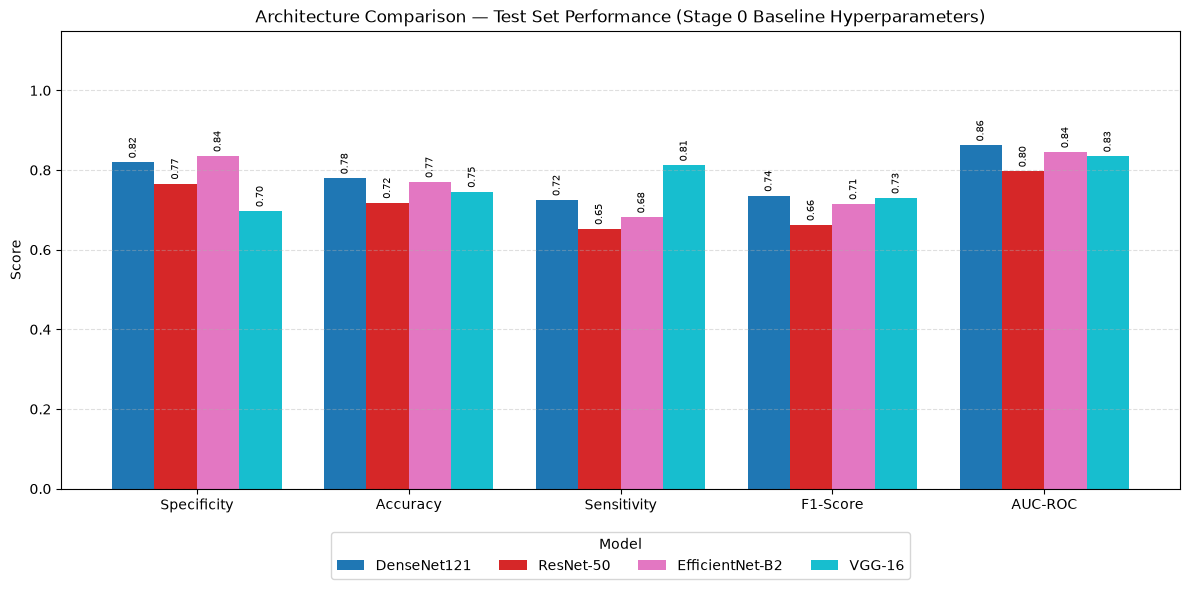

Saved comparison chart to results\architecture_comparison_chart.png

Best model by test accuracy: DenseNet121 (accuracy=0.7791, roc_auc=0.8617)


In [14]:
# --- Final comparison chart: Specificity, Accuracy, Sensitivity, F1-Score, AUC-ROC ---
metric_cols = ["specificity", "accuracy", "sensitivity", "f1", "roc_auc"]
metric_labels = ["Specificity", "Accuracy", "Sensitivity", "F1-Score", "AUC-ROC"]

models_order = comparison_df["model"].tolist()
x = np.arange(len(metric_cols))
n_models = len(models_order)
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10(np.linspace(0, 1, n_models))

for i, model_name in enumerate(models_order):
    row = comparison_df[comparison_df["model"] == model_name].iloc[0]
    values = [row[c] for c in metric_cols]
    offset = (i - (n_models - 1) / 2) * width
    bars = ax.bar(x + offset, values, width, label=model_name, color=colors[i])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.15)
ax.set_title("Architecture Comparison — Test Set Performance (Stage 0 Baseline Hyperparameters)")
ax.legend(title="Model", loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=n_models)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
comparison_fig_path = os.path.join(RESULTS_DIR, "architecture_comparison_chart.png")
plt.savefig(comparison_fig_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved comparison chart to {comparison_fig_path}")

best_model_row = comparison_df.loc[comparison_df["accuracy"].idxmax()]
print(f"\nBest model by test accuracy: {best_model_row['model']} "
      f"(accuracy={best_model_row['accuracy']:.4f}, roc_auc={best_model_row['roc_auc']:.4f})")
